In [1]:
###############################################################
# BLOQUE 1. IMPORTACION DE LIBRERIAS
#
# Carga las librerías necesarias para:
# - Manejo de arreglos numéricos (NumPy).
# - Construcción de gráficas (Matplotlib).
# - Ejecución de modelos MODFLOW 6 mediante FloPy.
# - Funciones auxiliares de flujo y transporte.
# - Lectura y escritura de archivos geoquímicos YESO.
#
# También se importan módulos propios para:
# - Construcción de modelos GWF y GWT.
# - Visualización de resultados.
# - Interacción con REMIX.
###############################################################
###############################################################
# BLOQUE 1. IMPORTACION DE LIBRERIAS
# Manejo de archivos, arreglos, graficas y modelos GWF/GWT.
# xmf6 y denit contienen funciones auxiliares para flujo,
# transporte, lectura de resultados y visualizacion.
###############################################################

import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xmf6
#from denit import gwf, gwt, plot, utils
from denit import plot, utils
from denit import gwfO as gwf
from denit import gwtO as gwt

linea = 50*chr(0x2015)

In [2]:
###############################################################
# BLOQUE 2. DEFINICION DE RUTAS Y PARAMETROS DEL MODELO
# En esta sección se define:
# 1. Ubicación del ejecutable MODFLOW 6.
# 2. Carpetas de trabajo para flujo y transporte.
# 3. Archivos geoquímicos del problema YESO:
#      - u_init_yeso.dat
#      - u_tilde_yeso.dat
#      - u_new_yeso.out
#      - gypsum_quim_loc.dat
#      - gypsum_sist_quim.dat
#      - gypsum_tar_sol.dat
#      - gypsum_tar_wat.dat
#
# 4. Parámetros físicos:
#      - Número de columnas.
#      - Longitud del dominio.
#      - Porosidad.
#      - Dispersividad.
#      - Tiempo de simulación.
#
# 5. Condiciones iniciales de componentes y especies.
#
# Finalmente se construyen las estructuras de datos
# que serán utilizadas durante todo el ciclo acoplado
# GWF-GWT-REMIX.
###############################################################
###############################################################
# BLOQUE 2. DEFINICION DE RUTAS Y PARAMETROS DEL MODELO
# Se definen archivos de entrada y salida.
# Tambien se construyen las condiciones iniciales,
# discretizacion espacial, tiempos y propiedades fisicas.
###############################################################
#
# --- DEFINICIÓN DE LAS RUTAS Y NOMBRES ---
#
paths = dict(
    # Ejecutable de Modflow: WINDOWS
    mf6_exe = r"C:\Users\luiggi\Documents\GitSites\mf6_tutorial\mf6\windows\mf6",
    #mf6_dll = r"C:\Users\luiggi\Documents\GitSites\mf6_tutorial\mf6\windows\libmf6.dll",
    #
    # Nombre de los modelos de flujo y transp y espacios de trabajo
    flow_name = "flow",
    flow_ws = "mf6_gwf_gwt_comp", 
    tran_name = "transport",
    tran_ws = "mf6_gwf_gwt_comp",
    #
    # Nombre de los archivos de datos para YESO
    u_init = os.path.join("remix", "u_init_yeso.dat"),
    u_tilde = os.path.join("remix", "u_tilde_yeso.dat"),
    u_new = os.path.join("remix", "u_new_yeso.out"),
    #
    # Archivos de datos geoquimicos para YESO
    quim_loc = os.path.join("remix", "gypsum_quim_loc.dat"),
    sist_quim = os.path.join("remix", "gypsum_sist_quim.dat"),
    tar_sol = os.path.join("remix", "gypsum_tar_sol.dat"),
    tar_wat = os.path.join("remix", "gypsum_tar_wat.dat"),
    #
    # Ejecutable REMIX y archivo de entrada
    remix_exe = os.path.join("remix", "bin", "interfaz_remix.exe"),
    remix_input = os.path.join("datos_interfaz_gypsum"),
)
paths["command"] = f"{paths['remix_exe']} < {paths['remix_input']}"
#
# --- DEFINIENDO CONDICIONES INICIALES ---
#

print("\nDEBUG")
print("u_init =", paths["u_init"])
print("Existe =", os.path.isfile(paths["u_init"]))

print(linea)
print("Generating initial conditions".center(50))
components, especies = utils.initial_conditions(paths, comp = True, spec=True)
ncomp = len(components["names"]) # "ca+2 - so4-2", "cl-"
print(linea)
#
xmf6.nice_print("Paths and filenames", paths)
#
# --- DATOS PARA LA SIMULACIÓN ---
#
# Paso del tiempo
dt = 1.0e0
NT = 40 #repeticiones del ciclo externo
#
# Discretización del espacio
nlay, nrow, ncol = 1, 1, 30
delr, delc, delz = 1, 1, 1  #0.1, 1, 1 (dx,dy,dz)
dis = {
    'length_units' : "meters",
    'nlay': nlay, 
    'nrow': nrow, 
    'ncol': ncol,
    'delr': delr, 
    'delc': delc, 
    'top' : delz, 
    'botm': 0.0 
}
xmf6.nice_print("Spatial discretization", dis)
#
# Parámetros físicos.
phys = dict(
    perioddata = [(dt, 1, 1.0)], #PERLEN, NSTP, TSMULT 
    porosity = 0.5,  # Porosity of mobile domain (unitless)
    hydraulic_conductivity = 1.0,  # Hydraulic conductivity ($cm s^{-1}$)
    inflow = 0.2,  # inflow ($m d^{-1}$)
    longitudinal_dispersivity = 0.5, # = 0.5 para denit
    components = components["names"], # Components names
    source_concentration = components["ext_water"],  # Source concentration (unitless)
    initial_concentration = components["init_conc"], # Initial concentration (unitless)
)
xmf6.nice_print("Physical parameters", phys)


DEBUG
u_init = remix\u_init_yeso.dat
Existe = True
――――――――――――――――――――――――――――――――――――――――――――――――――
          Generating initial conditions           
-> File remix\u_init_yeso.dat already exist
――――――――――――――――――――――――――――――――――――――――――――――――――

Paths and filenames
―――――――――――――――――――
    mf6_exe = C:\Users\luiggi\Documents\GitSites\mf6_tutorial\mf6\windows\mf6
  flow_name = flow
    flow_ws = mf6_gwf_gwt_comp
  tran_name = transport
    tran_ws = mf6_gwf_gwt_comp
     u_init = remix\u_init_yeso.dat
    u_tilde = remix\u_tilde_yeso.dat
      u_new = remix\u_new_yeso.out
   quim_loc = remix\gypsum_quim_loc.dat
  sist_quim = remix\gypsum_sist_quim.dat
    tar_sol = remix\gypsum_tar_sol.dat
    tar_wat = remix\gypsum_tar_wat.dat
  remix_exe = remix\bin\interfaz_remix.exe
remix_input = datos_interfaz_gypsum
    command = remix\bin\interfaz_remix.exe < datos_interfaz_gypsum
―――――――――――――――――――

Spatial discretization
――――――――――――――――――――――
length_units = meters
        nlay = 1
        

――――――――――――――――――――――――――――――――――――――――――――――――――
             Step = 10, time = 10.0d              
――――――――――――――――――――――――――――――――――――――――――――――――――
 GWF-GWT: C1 | GWF-GWT: C2 |
-> Writting: u_tilde_yeso.dat


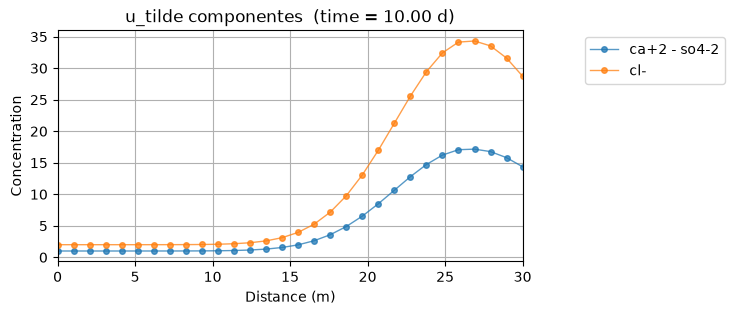


-> Executing: remix\bin\interfaz_remix.exe < datos_interfaz_gypsum

-> Error code: 1
-> Reading: remix\u_new_yeso.out

--- DEBUG ---
len(x[0]) = 30
ncomp = 2
u_new[0] = 30
u_new[1] = 30
ncol = 30

Contenido de u_new_yeso.out:

0 12  Aqueous component concentrations after solving reactive mixing iteration (rows: components, columns: targets):
1 0 
2 30       1.00001E+00    1.00002E+00    1.00003E+00    1.00007E+00    1.00018E+00    1.00048E+00    1.00127E+00    1.00325E+00    1.00799E+00    1.01875E+00    1.04204E+00    1.08987E+00    1.18299E+00    1.35432E+00    1.65170E+00    2.13757E+00    2.88315E+00    3.95516E+00    5.39542E+00    7.19729E+00    9.28626E+00    1.15136E+01    1.36692E+01    1.55137E+01    1.68218E+01    1.73834E+01    1.72583E+01    1.66183E+01    1.53917E+01    1.37330E+01
3 30       2.00002E+00    2.00003E+00    2.00005E+00    2.00013E+00    2.00036E+00    2.00096E+00    2.00255E+00    2.00652E+00    2.01598E+00    2.03750E+00    2.08407E+00    2.17975E+00    2

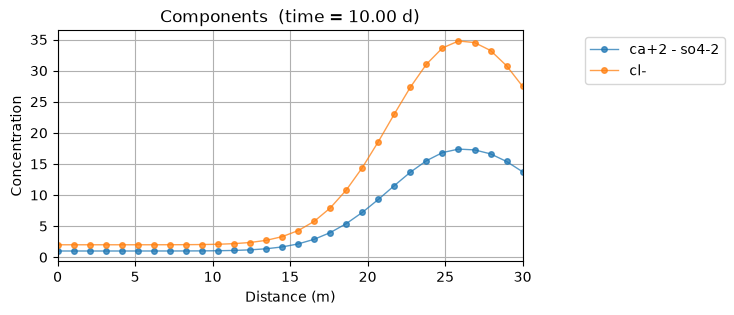

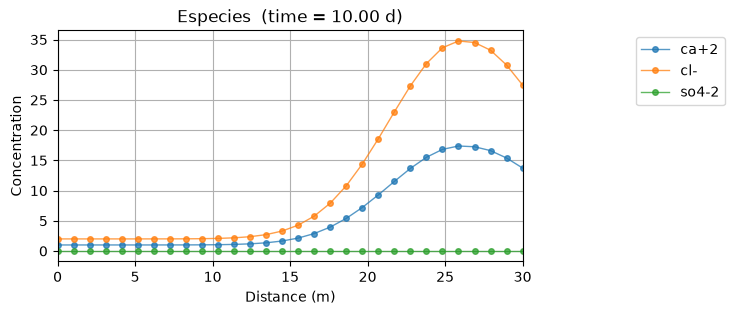

――――――――――――――――――――――――――――――――――――――――――――――――――
             Step = 20, time = 20.0d              
――――――――――――――――――――――――――――――――――――――――――――――――――
 GWF-GWT: C1 | GWF-GWT: C2 |
-> Writting: u_tilde_yeso.dat


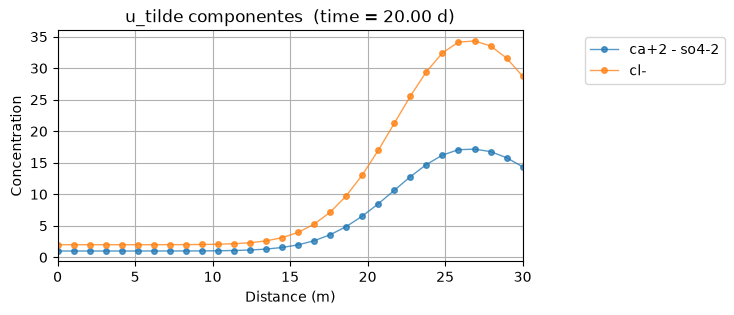


-> Executing: remix\bin\interfaz_remix.exe < datos_interfaz_gypsum

-> Error code: 1
-> Reading: remix\u_new_yeso.out

--- DEBUG ---
len(x[0]) = 30
ncomp = 2
u_new[0] = 30
u_new[1] = 30
ncol = 30

Contenido de u_new_yeso.out:

0 12  Aqueous component concentrations after solving reactive mixing iteration (rows: components, columns: targets):
1 0 
2 30       1.00001E+00    1.00002E+00    1.00003E+00    1.00007E+00    1.00018E+00    1.00048E+00    1.00127E+00    1.00325E+00    1.00799E+00    1.01875E+00    1.04204E+00    1.08987E+00    1.18299E+00    1.35432E+00    1.65170E+00    2.13757E+00    2.88315E+00    3.95516E+00    5.39542E+00    7.19729E+00    9.28626E+00    1.15136E+01    1.36692E+01    1.55137E+01    1.68218E+01    1.73834E+01    1.72583E+01    1.66183E+01    1.53917E+01    1.37330E+01
3 30       2.00002E+00    2.00003E+00    2.00005E+00    2.00013E+00    2.00036E+00    2.00096E+00    2.00255E+00    2.00652E+00    2.01598E+00    2.03750E+00    2.08407E+00    2.17975E+00    2

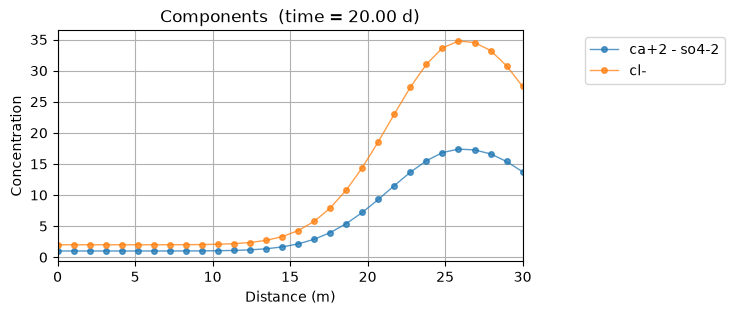

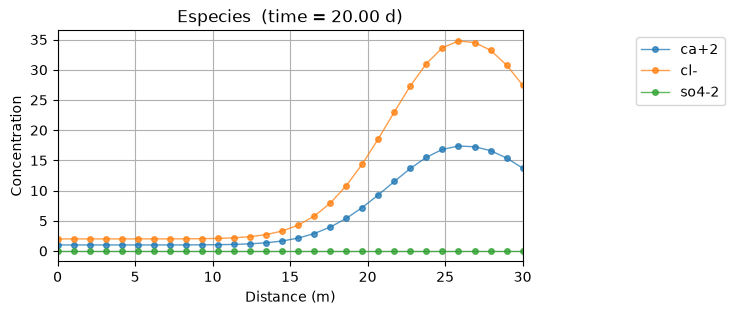

――――――――――――――――――――――――――――――――――――――――――――――――――
             Step = 30, time = 30.0d              
――――――――――――――――――――――――――――――――――――――――――――――――――
 GWF-GWT: C1 | GWF-GWT: C2 |
-> Writting: u_tilde_yeso.dat


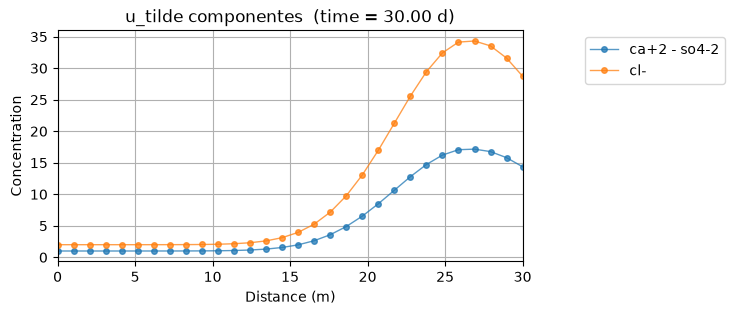


-> Executing: remix\bin\interfaz_remix.exe < datos_interfaz_gypsum

-> Error code: 1
-> Reading: remix\u_new_yeso.out

--- DEBUG ---
len(x[0]) = 30
ncomp = 2
u_new[0] = 30
u_new[1] = 30
ncol = 30

Contenido de u_new_yeso.out:

0 12  Aqueous component concentrations after solving reactive mixing iteration (rows: components, columns: targets):
1 0 
2 30       1.00001E+00    1.00002E+00    1.00003E+00    1.00007E+00    1.00018E+00    1.00048E+00    1.00127E+00    1.00325E+00    1.00799E+00    1.01875E+00    1.04204E+00    1.08987E+00    1.18299E+00    1.35432E+00    1.65170E+00    2.13757E+00    2.88315E+00    3.95516E+00    5.39542E+00    7.19729E+00    9.28626E+00    1.15136E+01    1.36692E+01    1.55137E+01    1.68218E+01    1.73834E+01    1.72583E+01    1.66183E+01    1.53917E+01    1.37330E+01
3 30       2.00002E+00    2.00003E+00    2.00005E+00    2.00013E+00    2.00036E+00    2.00096E+00    2.00255E+00    2.00652E+00    2.01598E+00    2.03750E+00    2.08407E+00    2.17975E+00    2

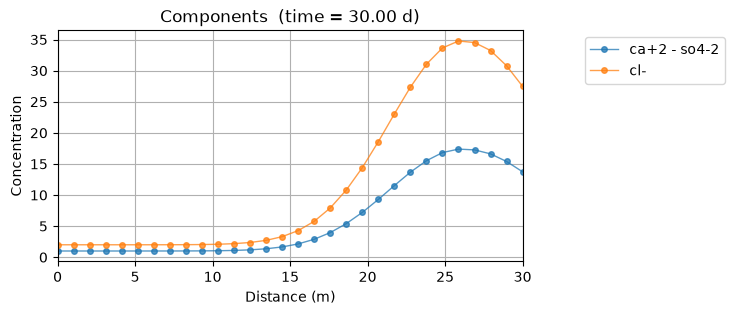

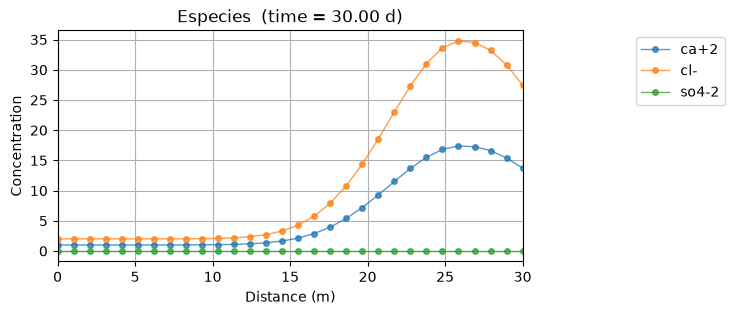

――――――――――――――――――――――――――――――――――――――――――――――――――
             Step = 40, time = 40.0d              
――――――――――――――――――――――――――――――――――――――――――――――――――
 GWF-GWT: C1 | GWF-GWT: C2 |
-> Writting: u_tilde_yeso.dat


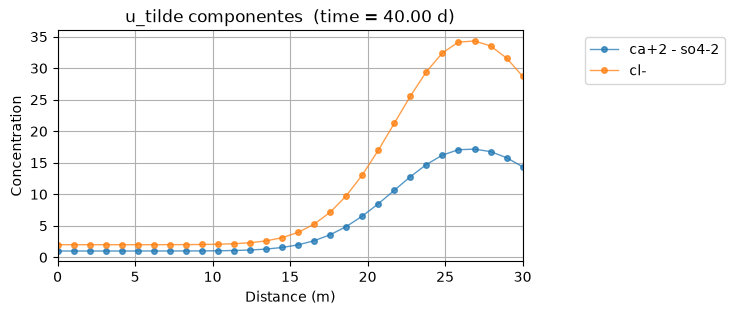


-> Executing: remix\bin\interfaz_remix.exe < datos_interfaz_gypsum

-> Error code: 1
-> Reading: remix\u_new_yeso.out

--- DEBUG ---
len(x[0]) = 30
ncomp = 2
u_new[0] = 30
u_new[1] = 30
ncol = 30

Contenido de u_new_yeso.out:

0 12  Aqueous component concentrations after solving reactive mixing iteration (rows: components, columns: targets):
1 0 
2 30       1.00001E+00    1.00002E+00    1.00003E+00    1.00007E+00    1.00018E+00    1.00048E+00    1.00127E+00    1.00325E+00    1.00799E+00    1.01875E+00    1.04204E+00    1.08987E+00    1.18299E+00    1.35432E+00    1.65170E+00    2.13757E+00    2.88315E+00    3.95516E+00    5.39542E+00    7.19729E+00    9.28626E+00    1.15136E+01    1.36692E+01    1.55137E+01    1.68218E+01    1.73834E+01    1.72583E+01    1.66183E+01    1.53917E+01    1.37330E+01
3 30       2.00002E+00    2.00003E+00    2.00005E+00    2.00013E+00    2.00036E+00    2.00096E+00    2.00255E+00    2.00652E+00    2.01598E+00    2.03750E+00    2.08407E+00    2.17975E+00    2

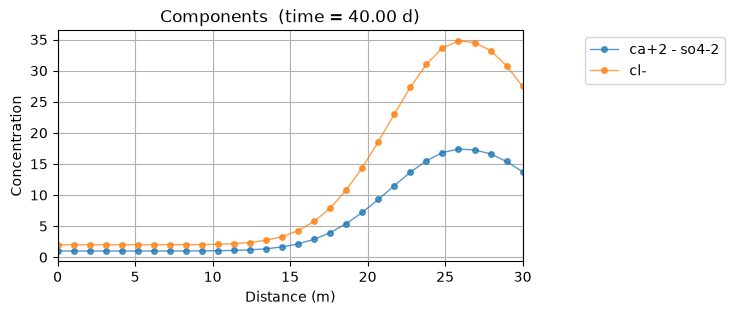

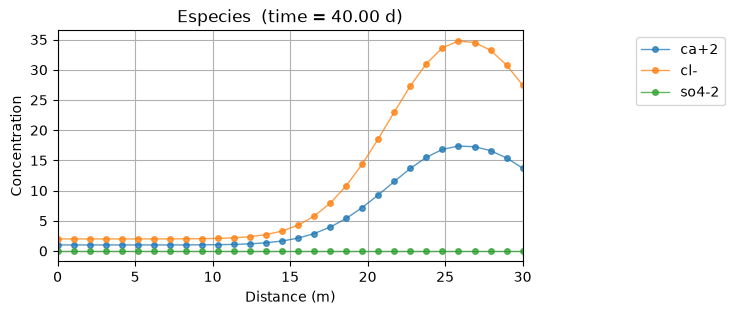

In [3]:
###############################################################
# BLOQUE 3. CICLO PRINCIPAL GWF-GWT-REMIX
# Este bloque constituye el núcleo de la simulación.
# Para cada paso de tiempo se ejecuta:
#   Paso 1:
#       Resolver flujo subterráneo (GWF).
#   Paso 2:
#       Resolver transporte de cada componente (GWT).
#   Paso 3:
#       Construir u_tilde_yeso.dat con las
#       concentraciones transportadas.
#   Paso 4:
#       Ejecutar REMIX para resolver el equilibrio
#       geoquímico local.
#   Paso 5:
#       Leer u_new_yeso.out generado por REMIX.
#   Paso 6:
#       Actualizar componentes y especies para el
#       siguiente paso temporal.
###############################################################
# ==========================================================
# Tiempos donde se desea imprimir y graficar
# ==========================================================

tiempos_plot = [10, 20, 30, 40]

u_tilde = [0 for i in range(ncomp)]

for it in range(1, NT + 1):

    if it in tiempos_plot:
        print(linea)
        print(f"Step = {it}, time = {it*dt}d".center(50))
        print(linea)

    # =====================================================
    # GWF + GWT para cada componente
    # =====================================================

    for m in range(ncomp):

        # -------------------------------------------------
        # GWF
        # -------------------------------------------------

        o_sim_f = gwf.build(
            phys,
            dis,
            m,
            paths
        )

        if it in tiempos_plot:
            print(" GWF", end="")

        o_sim_f.run_simulation(
            silent=True
        )

        # -------------------------------------------------
        # GWT
        # -------------------------------------------------

        o_sim_t = gwt.build(
            phys,
            dis,
            m,
            paths
        )

        if it in tiempos_plot:
            print(
                f"-GWT: C{m+1}",
                end=" |"
            )

        o_sim_t.run_simulation(
            silent=True
        )

        # -------------------------------------------------
        # Concentración calculada
        # -------------------------------------------------

        u_tilde[m] = utils.get_conc(
            o_sim_t
        )

    # =====================================================
    # Guardar u_tilde_yeso.dat
    # =====================================================

    if it in tiempos_plot:
        print("\n-> Writting: u_tilde_yeso.dat")

    with open(paths["u_tilde"], "w") as f:

        for a in u_tilde:

            f.write(
                " ".join(a.astype(str))
            )

            f.write("\n")

    # =====================================================
    # Preparar eje X
    # =====================================================

    U_tilde = np.array(u_tilde)

    x = [np.linspace(
            0,
            ncol * delr,
            U_tilde.shape[1]
         )]

    # =====================================================
    # Graficar u_tilde SOLO en 10,20,30,40
    # =====================================================

    if it in tiempos_plot:

        plot.show_t(
            U_tilde,
            components["names"],
            x,
            None,
            None,
            ncol=ncol,
            delr=delr,
            yscale="linear",
            title="u_tilde componentes",
            time=it * dt
        )

    # =====================================================
    # Ejecutar REMIX
    # =====================================================

    if it in tiempos_plot:
        print(f"\n-> Executing: {paths['command']}")

    ret = os.system(
        paths["command"]
    )

    if it in tiempos_plot:
        print(f"\n-> Error code: {ret}")

    # =====================================================
    # Leer u_new_yeso.out
    # =====================================================

    if it in tiempos_plot:
        print(f"-> Reading: {paths['u_new']}")

    with open(
        paths["u_new"],
        "r"
    ) as f:

        lines = f.readlines()

    # =====================================================
    # Componentes después de REMIX
    # =====================================================

    key_string = (
        "Aqueous component concentrations after solving reactive mixing iteration (rows: components, columns: targets):"
    )

    iccn = utils.find_index(
        lines,
        key_string,
        2
    )

    u_new = [

        np.array(
            l.split(),
            dtype=float
        )

        for l in lines[
            iccn:iccn+ncomp
        ]

    ]

    # =====================================================
    # Actualizar condiciones iniciales
    # =====================================================

    phys["initial_concentration"] = u_new

    # =====================================================
    # Leer especies
    # =====================================================

    key_string = (
        "Concentrations of variable activity species after solving reactive mixing iteration (rows: species, columns: targets):"
    )

    iccn_s = utils.find_index(
        lines,
        key_string,
        2
    )

    s_new = [

        np.array(
            l.split(),
            dtype=float
        )

        for l in lines[
            iccn_s:
            iccn_s + len(especies["names"])
        ]

    ]

    # =====================================================
    # DEBUG SOLO EN 10,20,30,40
    # =====================================================

    if it in tiempos_plot:

        print("\n--- DEBUG ---")

        print(
            "len(x[0]) =",
            len(x[0])
        )

        print(
            "ncomp =",
            len(u_new)
        )

        for i, u in enumerate(u_new):

            print(
                f"u_new[{i}] =",
                len(u)
            )

        print(
            "ncol =",
            ncol
        )

        print(
            "\nContenido de u_new_yeso.out:\n"
        )

        with open(
            paths["u_new"],
            "r"
        ) as f:

            for i in range(10):

                linea_tmp = f.readline()

                print(
                    i,
                    len(linea_tmp.split()),
                    linea_tmp.rstrip()
                )

    # =====================================================
    # Graficar componentes
    # =====================================================

    if it in tiempos_plot:

        plot.show_t(
            u_new,
            components["names"],
            x,
            None,
            None,
            ncol=ncol,
            delr=delr,
            yscale="linear",
            title="Components",
            time=it * dt
        )

    # =====================================================
    # Graficar especies
    # =====================================================

    if it in tiempos_plot:

        plot.show_t(
            s_new,
            especies["names"],
            x,
            None,
            None,
            ncol=ncol,
            delr=delr,
            yscale="linear",
            title="Especies",
            time=it * dt
        )

In [4]:
###############################################################
# BLOQUE 4. LECTURA DE RESULTADOS DE REMIX
#
# Se leen las concentraciones finales calculadas
# por REMIX después de resolver las reacciones.
#
# El archivo u_new_yeso.out contiene:
#
#   - Componentes conservativos.
#   - Especies químicas.
#
# Estas concentraciones serán utilizadas para:
#
#   - Actualizar condiciones iniciales.
#   - Construir gráficas.
#   - Comparar con soluciones analíticas.
###############################################################
###############################################################
# BLOQUE 4. LECTURA DE RESULTADOS DE REMIX
# Lee componentes y especies desde u_new_yeso.out.
# Estas concentraciones seran usadas para analisis y graficas.
###############################################################

# --- Leemos las concentraciones de las componentes calculadas por REMIX
print(f"-> Reading: {paths['u_new']}")
with open(paths["u_new"], "r") as f:
    lines = f.readlines()


# Actualizamos las concentraciones para GWT
key_string = "Concentrations of variable activity species after solving reactive mixing iteration (rows: species, columns: targets):"
iccn = utils.find_index(lines, key_string, 2)
s_new = [np.array(l.split(), dtype=float) for l in lines[iccn:iccn+ncomp+1]]


-> Reading: remix\u_new_yeso.out


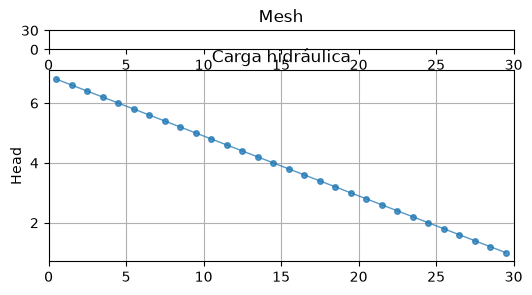

In [5]:
###############################################################
# BLOQUE 5. VISUALIZACION DEL FLUJO
#
# Recupera la solución hidráulica obtenida
# por MODFLOW 6.
#
# Se muestran:
#
#   - Carga hidráulica.
#   - Malla espacial.
#   - Coordenadas de los centros de celda.
#
# Esta gráfica permite verificar que el campo
# de flujo es consistente antes de analizar
# el transporte reactivo.
###############################################################
###############################################################
# BLOQUE 5. VISUALIZACION DEL FLUJO
# Recupera la carga hidraulica calculada por GWF.
###############################################################

o_gwf, head, x, y, z = utils.get_head(o_sim_f)
plot.show_f(o_gwf, head, x, y, z, ncol=ncol, delr=delr)

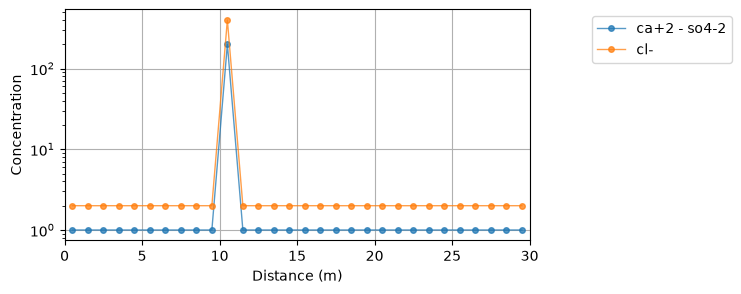

In [6]:
###############################################################
# BLOQUE 6. COMPONENTES INICIALES
#
# Grafica las concentraciones iniciales de los
# componentes químicos definidos en u_init_yeso.dat.
#
# Estas curvas representan el estado del sistema
# antes de comenzar la simulación de transporte
# y reacciones geoquímicas.
###############################################################
###############################################################
# BLOQUE 6. COMPONENTES INICIALES
# Grafica las concentraciones iniciales.
###############################################################

plot.show_t(components["init_conc"], components["names"], x, y, z, ncol=ncol, delr=delr, yscale="log")

In [7]:
###############################################################
# BLOQUE 7. IMPRESION DE COMPONENTES INICIALES
#
# Imprime en pantalla las concentraciones
# iniciales de cada componente químico.
#
# Esta salida sirve para verificar que los
# datos fueron leídos correctamente desde
# u_init_yeso.dat.
###############################################################
###############################################################
# BLOQUE 7. IMPRESION DE COMPONENTES INICIALES
###############################################################

print(components["init_conc"])

[array([  1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1., 200.,
         1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,
         1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.]), array([  2.,   2.,   2.,   2.,   2.,   2.,   2.,   2.,   2.,   2., 400.,
         2.,   2.,   2.,   2.,   2.,   2.,   2.,   2.,   2.,   2.,   2.,
         2.,   2.,   2.,   2.,   2.,   2.,   2.,   2.])]


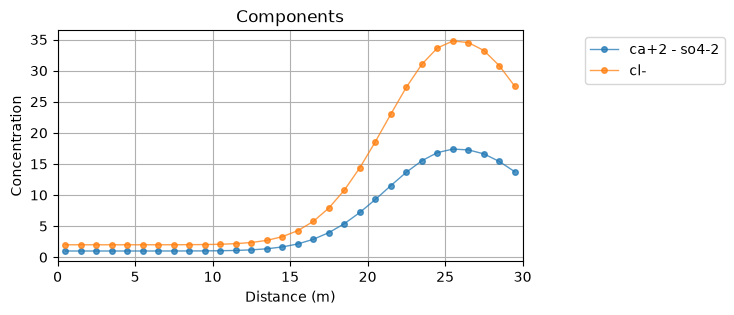

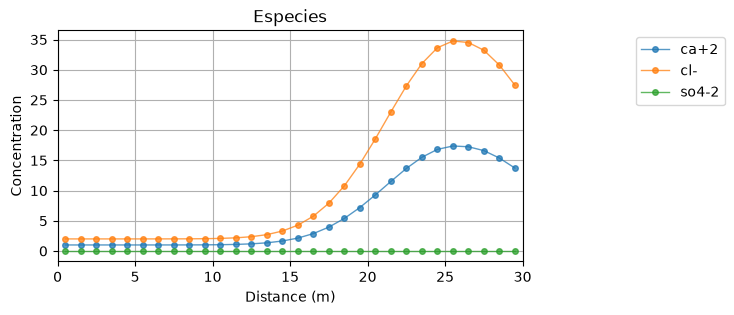

In [8]:
###############################################################
# BLOQUE 8. COMPONENTES Y ESPECIES DESPUES DE REMIX
#
# Visualiza las concentraciones obtenidas
# después de la etapa geoquímica.
#
# Se muestran:
#
#   - Componentes actualizados (u_new).
#   - Especies químicas actualizadas (s_new).
#
# Estas gráficas permiten evaluar el efecto
# de las reacciones químicas sobre el sistema.
###############################################################
###############################################################
# BLOQUE 8. COMPONENTES Y ESPECIES DESPUES DE REMIX
# Muestra las componentes y especies actualizadas.
###############################################################
plot.show_t(u_new, components["names"], x, y, z, ncol=ncol, delr=delr, yscale="linear", title="Components")
plot.show_t(s_new, especies["names"], x, y, z, ncol=ncol, delr=delr, yscale="linear", title="Especies")

In [9]:
###############################################################
# BLOQUE 9. DEPURACION OPCIONAL
#
# Permite imprimir directamente los arreglos:
#
#   - u_new
#   - s_new
#
# para inspeccionar los resultados numéricos
# sin utilizar gráficas.
###############################################################
#print(u_new) 
#print(s_new)

# Grafica u_new_yeso.out vs SNBN.txt

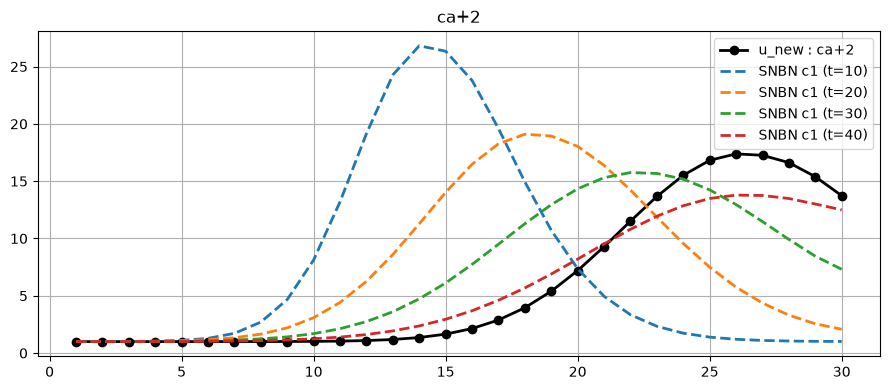

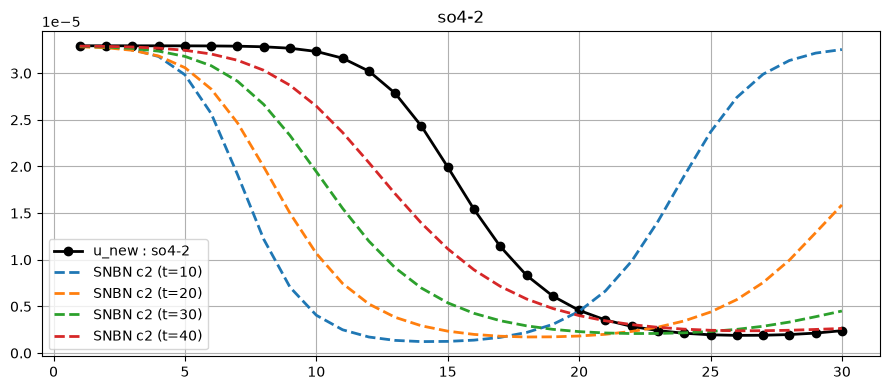

In [10]:
###############################################################
# BLOQUE 10. COMPARACION DE ESPECIES ENTRE REMIX Y SNBN
#
# Este bloque compara las especies químicas calculadas por
# REMIX (u_new_yeso.out) contra las especies obtenidas a
# partir de la solución de referencia SNBN.txt.
#
# Se analizan las especies:
#
#   - Ca+2
#   - SO4-2
#
# para los tiempos:
#
#   10, 20, 30 y 40
#
# El objetivo es evaluar el grado de concordancia entre la
# solución numérica y la solución de referencia.
###############################################################

import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# Lectura de u_new_yeso.out
#
# Se carga el archivo generado por REMIX después de resolver
# el equilibrio geoquímico.
#
# Este archivo contiene:
#
#   - Componentes químicas.
#   - Especies químicas.
#
# almacenadas por renglones.
# ==========================================================

with open(r".\remix\u_new_yeso.out") as f:
    lineas = [l.rstrip() for l in f]

# ==========================================================
# Localización del bloque de especies
#
# Se busca el encabezado:
#
#   "Concentrations of variable activity species"
#
# para identificar dónde comienzan las especies dentro
# del archivo u_new_yeso.out.
# ==========================================================

idx = next(
    i for i,l in enumerate(lineas)
    if "Concentrations of variable activity species" in l
)

# ==========================================================
# Extracción de especies químicas
#
# A partir del encabezado encontrado se recuperan:
#
#   ca  = Ca+2
#   cl  = Cl-
#   so4 = SO4-2
#
# Cada arreglo contiene la concentración en las 30 celdas
# del dominio.
# ==========================================================

ca = np.array(
    [float(x) for x in lineas[idx+2].split()]
)

cl = np.array(
    [float(x) for x in lineas[idx+3].split()]
)

so4 = np.array(
    [float(x) for x in lineas[idx+4].split()]
)

# ==========================================================
# Lectura de SNBN.txt
#
# El archivo SNBN.txt contiene:
#
#   - Componentes calculadas a partir de SNBN.
#   - Especies c1 y c2 para distintos tiempos.
#
# Se construirá un diccionario para almacenar los perfiles
# de referencia.
# ==========================================================

SNBN = {}

with open(r".\remix\SNBN.txt") as f:
    texto = f.readlines()

# ==========================================================
# Lectura de perfiles SNBN
#
# Para cada tiempo:
#
#   t = 10
#   t = 20
#   t = 30
#   t = 40
#
# se recuperan:
#
#   c1
#   c2
#
# y se almacenan dentro del diccionario SNBN.
# ==========================================================

for tiempo in [10,20,30,40]:

    pos = next(
        i for i,l in enumerate(texto)
        if f"TIEMPO = {tiempo}" in l
    )

    datos = []

    for linea in texto[pos+2:]:

        linea = linea.strip()

        if linea == "":
            break

        if linea.startswith("TIEMPO"):
            break

        datos.append(
            [float(x) for x in linea.split()]
        )

    datos = np.array(datos)

    SNBN[tiempo] = {
        "c1": datos[:,0],
        "c2": datos[:,1]
    }

# ==========================================================
# Grafica de Ca+2
#
# Se compara la especie Ca+2 calculada por REMIX contra
# los perfiles c1 obtenidos desde SNBN para los tiempos:
#
#   10, 20, 30 y 40
#
# La curva negra corresponde a la simulación numérica.
# Las curvas punteadas corresponden a la referencia SNBN.
# ==========================================================

plt.figure(figsize=(9,4))

x = np.arange(1, len(ca)+1)

plt.plot(
    x,
    ca,
    "ko-",
    lw=2,
    label="u_new : ca+2"
)

for t in [10,20,30,40]:

    plt.plot(
        x,
        SNBN[t]["c1"],
        "--",
        lw=2,
        label=f"SNBN c1 (t={t})"
    )

plt.title("ca+2")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ==========================================================
# Grafica de SO4-2
#
# Se compara la especie SO4-2 calculada por REMIX contra
# los perfiles c2 obtenidos desde SNBN para los tiempos:
#
#   10, 20, 30 y 40
#
# La curva negra corresponde a la simulación numérica.
# Las curvas punteadas corresponden a la referencia SNBN.
# ==========================================================

plt.figure(figsize=(9,4))

plt.plot(
    x,
    so4,
    "ko-",
    lw=2,
    label="u_new : so4-2"
)

for t in [10,20,30,40]:

    plt.plot(
        x,
        SNBN[t]["c2"],
        "--",
        lw=2,
        label=f"SNBN c2 (t={t})"
    )

plt.title("so4-2")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()